In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("decision.csv")
df

,CGPA,Communication,Aptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [4]:
x =df.drop('Job Offered',axis=1)
y = df['Job Offered']

In [5]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="entropy",max_depth=2,random_state=42)
dt.fit(x,y)


DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)

<function matplotlib.pyplot.show(close=None, block=None)>

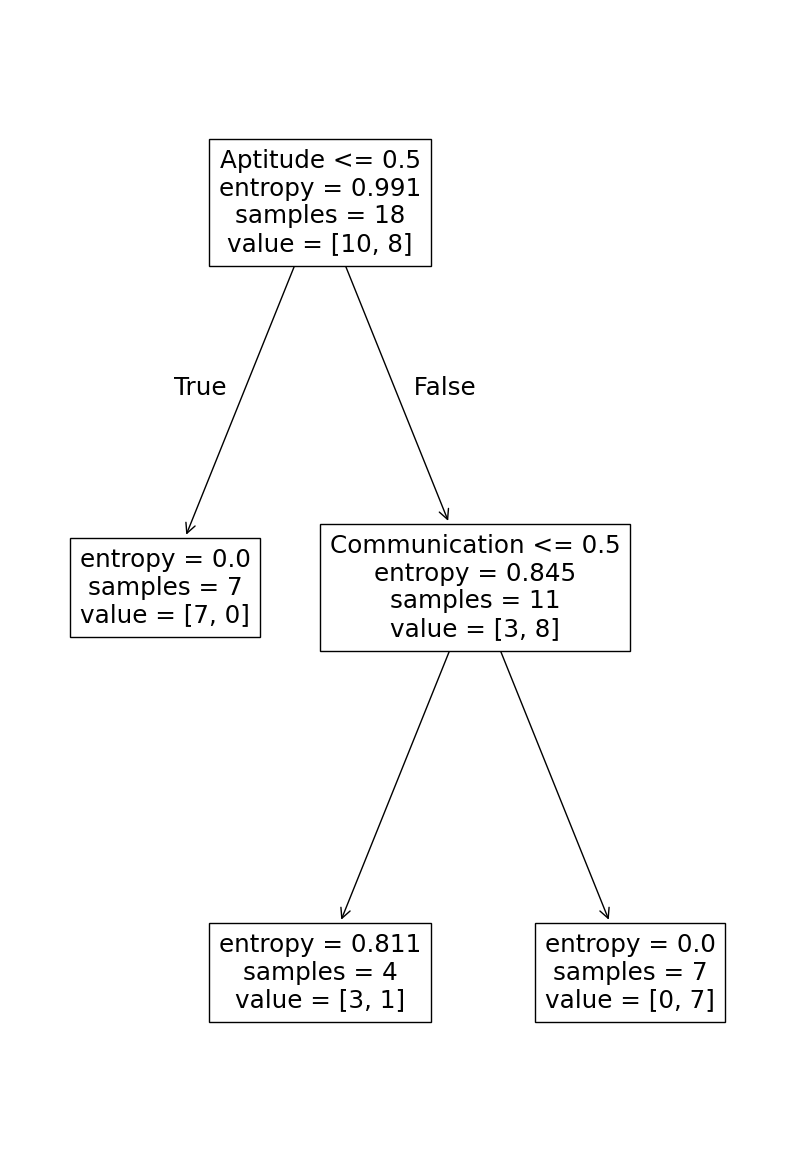

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,15))
plot_tree(dt,feature_names=x.columns,)
plt.show


In [7]:
df = pd.read_csv("Churn.csv")
df

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [8]:
df.drop(['Unnamed: 0','customerID'],inplace=True,axis=1)

In [9]:
df.dropna(inplace=True)

In [10]:
x = df.drop('Churn',axis=1)
y = df['Churn']

In [11]:
x = pd.get_dummies(x,drop_first=True)

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=21)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=21)

In [14]:
y_pred = knn.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[966  80]
 [195 166]]
              precision    recall  f1-score   support

          No       0.83      0.92      0.88      1046
         Yes       0.67      0.46      0.55       361

    accuracy                           0.80      1407
   macro avg       0.75      0.69      0.71      1407
weighted avg       0.79      0.80      0.79      1407



In [15]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="entropy",random_state=42)
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[851 195]
 [173 188]]
              precision    recall  f1-score   support

          No       0.83      0.81      0.82      1046
         Yes       0.49      0.52      0.51       361

    accuracy                           0.74      1407
   macro avg       0.66      0.67      0.66      1407
weighted avg       0.74      0.74      0.74      1407



In [16]:
# import matplotlib.pyplot as plt
# from sklearn.tree import plot_tree
# plt.figure(figsize=(150,150))
# plot_tree(dt,feature_names=x.columns)
# plt.savefig("decision.svg")
# plt.show


In [17]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score
print(accuracy_score(y_test,y_pred))
print(recall_score(y_test,y_pred,pos_label='Yes'))
print(precision_score(y_test,y_pred,pos_label='Yes'))
print(f1_score(y_test,y_pred,pos_label='Yes'))

0.738450604122246
0.5207756232686981
0.4908616187989556
0.5053763440860215


# A

In [18]:
df = pd.read_csv("loan_approval.csv")

In [19]:
df.head(5)

,Age,Income,CreditScore,LoanAmount,Dependents,Education,SelfEmployed,PropertyArea,PreviousLoans,LoanApproved
0,25,35000.0,620,120000.0,0,Graduate,No,Urban,1,No
1,42,72000.0,780,200000.0,2,Graduate,No,Semiurban,0,Yes
2,35,58000.0,690,150000.0,1,Graduate,Yes,Rural,2,Yes
3,28,26000.0,590,100000.0,0,Not Graduate,No,Urban,1,No
4,50,85000.0,810,250000.0,3,Graduate,No,Semiurban,0,Yes


In [20]:
df.shape

(13, 10)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            13 non-null     int64  
 1   Income         12 non-null     float64
 2   CreditScore    13 non-null     int64  
 3   LoanAmount     12 non-null     float64
 4   Dependents     13 non-null     int64  
 5   Education      13 non-null     object 
 6   SelfEmployed   13 non-null     object 
 7   PropertyArea   13 non-null     object 
 8   PreviousLoans  13 non-null     int64  
 9   LoanApproved   13 non-null     object 
dtypes: float64(2), int64(4), object(4)
memory usage: 1.1+ KB


# B


In [22]:
df.isna().sum()

Age              0
Income           1
CreditScore      0
LoanAmount       1
Dependents       0
Education        0
SelfEmployed     0
PropertyArea     0
PreviousLoans    0
LoanApproved     0
dtype: int64

In [23]:
df.fillna(df.median(numeric_only=True),inplace=True)
df

,Age,Income,CreditScore,LoanAmount,Dependents,Education,SelfEmployed,PropertyArea,PreviousLoans,LoanApproved
0,25,35000.0,620,120000.0,0,Graduate,No,Urban,1,No
1,42,72000.0,780,200000.0,2,Graduate,No,Semiurban,0,Yes
2,35,58000.0,690,150000.0,1,Graduate,Yes,Rural,2,Yes
3,28,26000.0,590,100000.0,0,Not Graduate,No,Urban,1,No
4,50,85000.0,810,250000.0,3,Graduate,No,Semiurban,0,Yes
5,31,46000.0,640,130000.0,1,Graduate,Yes,Rural,1,No
6,39,67000.0,730,180000.0,2,Graduate,No,Urban,0,Yes
7,29,31000.0,610,110000.0,0,Not Graduate,No,Rural,2,No
8,45,79000.0,800,230000.0,2,Graduate,No,Semiurban,0,Yes
9,33,52000.0,675,145000.0,1,Graduate,Yes,Urban,1,Yes


In [24]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11     True
12    False
dtype: bool

In [25]:
df.drop_duplicates(inplace=True)

In [26]:
df.duplicated()


0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
12    False
dtype: bool

In [27]:
df.shape

(12, 10)

# C

In [28]:
df3 =pd.get_dummies(df,drop_first=True)

In [29]:
x = df3.drop("LoanApproved_Yes",axis=1)
y = df3["LoanApproved_Yes"]

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


# D

In [31]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [32]:
y_pred = knn.predict(x_test)

In [33]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

a1 = accuracy_score(y_test,y_pred)
a2 = precision_score(y_test,y_pred)
a3 = recall_score(y_test,y_pred)
a4 = f1_score(y_test,y_pred)
a5 = confusion_matrix(y_test,y_pred)

print(a1)
print(a2)
print(a3)
print(a4)
print(a5)


0.6666666666666666
1.0
0.5
0.6666666666666666
[[1 0]
 [1 1]]


# E

In [34]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="entropy",max_depth=2,random_state=42)
dt.fit(x,y)
y_pred = dt.predict(x_test)

In [35]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

b1 = accuracy_score(y_test,y_pred)
b2 = precision_score(y_test,y_pred)
b3 = recall_score(y_test,y_pred)
b4 = f1_score(y_test,y_pred)
b5 = confusion_matrix(y_test,y_pred)
print(b1)
print(b2)
print(b3)
print(b4)
print(b5)


1.0
1.0
1.0
1.0
[[1 0]
 [0 2]]


<function matplotlib.pyplot.show(close=None, block=None)>

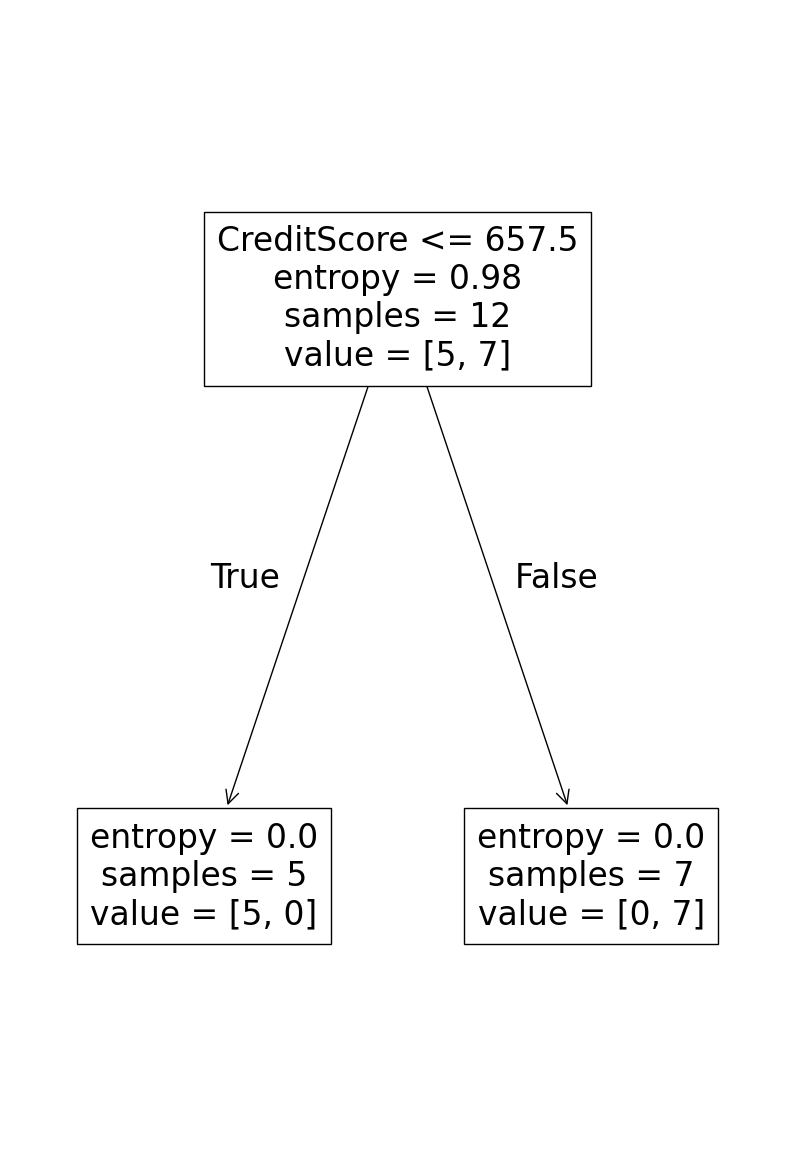

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,15))
plot_tree(dt,feature_names=x.columns)
plt.show

In [37]:
data = {
    'model' : ["KNN","Decision Tree"],
    'Accuracy' : [a1,b1],
    'Precision' : [a2,b2],
    'Recall' : [a3,b3],
    'F1_Score' : [a4,b4] }

df2 = pd.DataFrame(data)
df2


,model,Accuracy,Precision,Recall,F1_Score
0,KNN,0.666667,1.0,0.5,0.666667
1,Decision Tree,1.000000,1.0,1.0,1.000000


In [38]:
x = df['Income']
y = df['CreditScore']

<Axes: xlabel='Income', ylabel='CreditScore'>

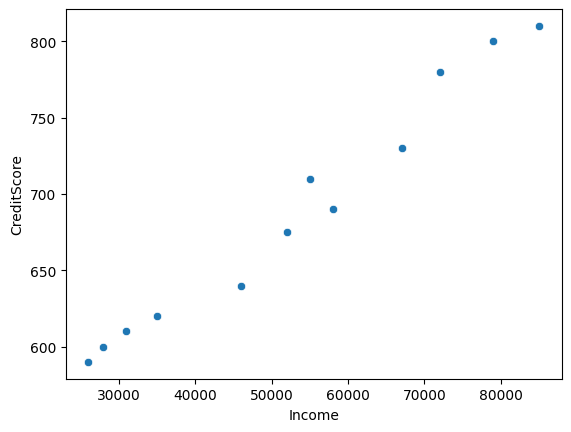

In [39]:
import seaborn as sns
sns.scatterplot(df,x=x,y=y)

<Axes: ylabel='LoanAmount'>

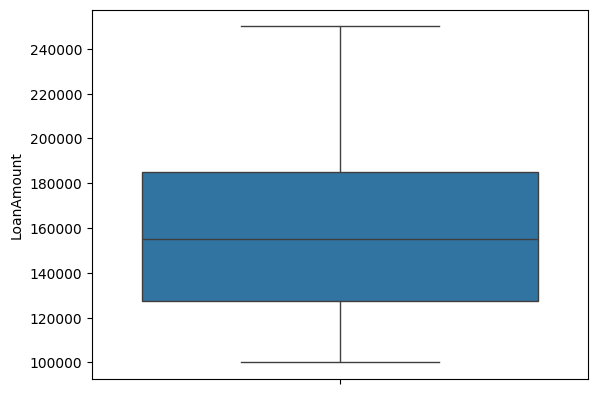

In [40]:
sns.boxplot(df['LoanAmount'])

<Axes: xlabel='Income', ylabel='CreditScore'>

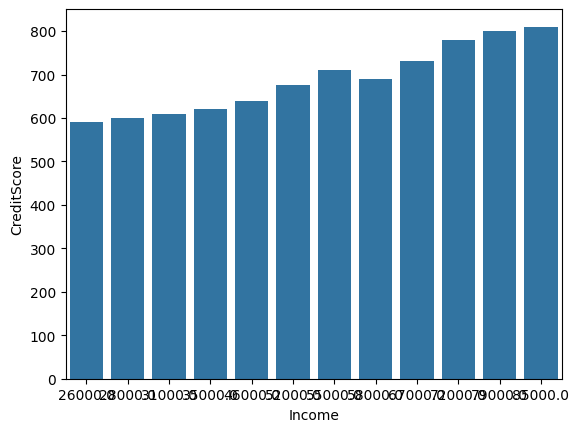

In [41]:
sns.barplot(df,x=x,y=y)

In [42]:
df.nunique()

Age              12
Income           12
CreditScore      12
LoanAmount       12
Dependents        4
Education         2
SelfEmployed      2
PropertyArea      3
PreviousLoans     3
LoanApproved      2
dtype: int64

In [43]:
import matplotlib.pyplot as plt

([<matplotlib.patches.Wedge at 0x23708442510>,
 [Text(-0.28470088329267024, 1.062518426688391, ''),
  Text(0.28470078381251407, -1.0625184533440069, '')])

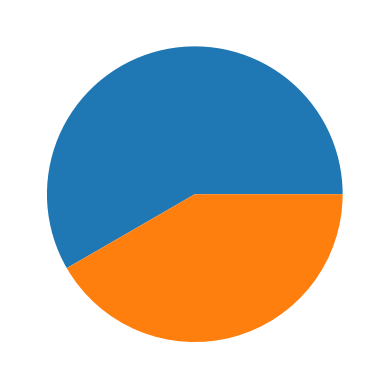

In [ ]:
plt.pie(df['LoanApproved'].value_counts())

In [ ]:
plt.pie